# Cross-Run Comparison Notebook

Confronta più run Christiano su un insieme di grafici aggregati.
Ogni run deve avere `debug_data.pkl` nella propria output dir.

**Non** carica i reward model: usa solo i `pred_rewards_mean` già salvati in `debug_data.pkl`.

Grafici inclusi:
1. Episode scatter (true vs predicted return)
2. Distribuzione errore step-level
3. Calibration curve
4. Logit distribution (da ritorni episodici)
5. Errore per posizione nell'episodio
6. Summary bar charts + tabella numerica

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pickle
from pathlib import Path
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── CONFIG: aggiungi / rimuovi run qui ─────────────────────────────────────
# Formato: "etichetta": Path("path/relativo/o/assoluto/alla/run_dir")
# La run_dir deve contenere debug_data.pkl

RUN_CONFIGS = {
    "seg_1_reg_ON":  Path("../outputs/train/2026-05-09_13-31-06_seg_1_reg_ON"),
    "seg_1_reg_OFF": Path("../outputs/train/2026-05-10_00-18-54_PPO_seg_1_reg_OFF"),
    "seg_50_reg_ON": Path("../outputs/train/2026-05-10_05-13-47_PPO_seg_50_reg_ON"),
    "seg_50_reg_OFF": Path("../outputs/train/2026-05-10_07-56-24_PPO_seg_50_reg_OFF")
}

# Palette: una per run, in ordine
PALETTE = plt.cm.tab10(np.linspace(0, 0.7, max(len(RUN_CONFIGS), 1)))

# ── Caricamento dati ───────────────────────────────────────────────────────
runs = {}   # label → dict con arrays pronti

for label, rdir in RUN_CONFIGS.items():
    dbg = rdir / "debug_data.pkl"
    if not dbg.exists():
        print(f"[SKIP] {label}: {dbg} non trovato")
        continue
    with open(dbg, "rb") as f:
        d = pickle.load(f)

    trajs   = d["trajectories"]
    ep_tr   = np.array(d["episode_true_returns"])
    ep_pr   = np.array(d["episode_pred_returns"])
    at      = np.concatenate([t["true_rewards"]      for t in trajs])
    ap      = np.concatenate([t["pred_rewards_mean"] for t in trajs])
    ae      = ap - at
    ep_gap  = ep_pr - ep_tr

    p_ep, _ = pearsonr(ep_tr, ep_pr)
    s_ep, _ = spearmanr(ep_tr, ep_pr)
    p_st, _ = pearsonr(at, ap)

    runs[label] = {
        "rdir":      rdir,
        "trajs":     trajs,
        "ep_tr":     ep_tr,
        "ep_pr":     ep_pr,
        "at":        at,
        "ap":        ap,
        "ae":        ae,
        "ep_gap":    ep_gap,
        "p_ep":      p_ep,
        "s_ep":      s_ep,
        "p_st":      p_st,
        "mae":       np.abs(ae).mean(),
        "bias":      ae.mean(),
        "expl_idx":  ep_gap.mean() / (ep_tr.std() + 1e-8),
        "pred_mean": ap.mean(),
        "pred_std":  ap.std(),
        "n_ep":      len(ep_tr),
        "n_steps":   len(at),
    }
    print(f"[OK] {label:30s} — {len(ep_tr)} episodi, {len(at)} step")

labels  = list(runs.keys())
colors  = {l: PALETTE[i] for i, l in enumerate(labels)}
print(f"\nRun caricate: {labels}")

[OK] seg_1_reg_ON                   — 18 episodi, 2241 step
[OK] seg_1_reg_OFF                  — 12 episodi, 2338 step
[OK] seg_50_reg_ON                  — 10 episodi, 2522 step
[OK] seg_50_reg_OFF                 — 16 episodi, 2337 step

Run caricate: ['seg_1_reg_ON', 'seg_1_reg_OFF', 'seg_50_reg_ON', 'seg_50_reg_OFF']


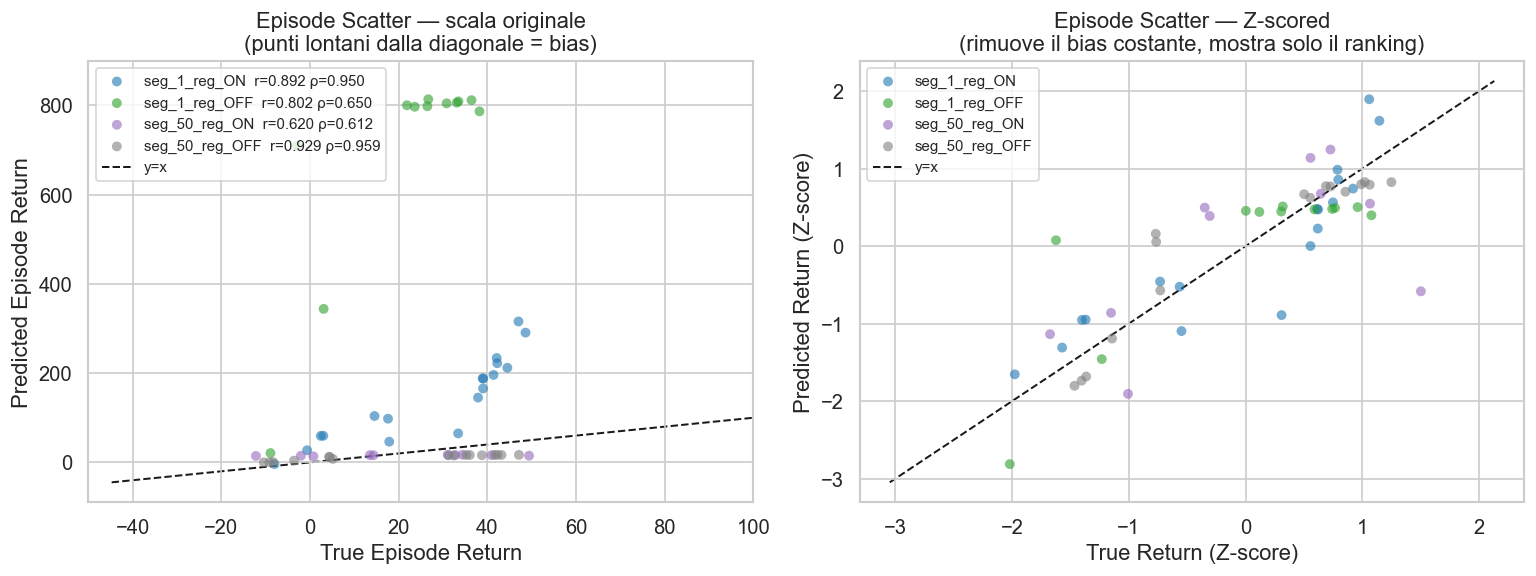

In [9]:
# ── 1. Episode scatter: true vs predicted return ───────────────────────────
# Ogni run è un colore diverso; le diagonali y=x aiutano a leggere il bias.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, r in runs.items():
    c = colors[label]
    # Raw
    axes[0].scatter(r["ep_tr"], r["ep_pr"], color=c, alpha=0.6, s=35,
                    edgecolors="none", label=f"{label}  r={r['p_ep']:.3f} ρ={r['s_ep']:.3f}")
    # Z-scored
    tz = (r["ep_tr"] - r["ep_tr"].mean()) / (r["ep_tr"].std() + 1e-8)
    pz = (r["ep_pr"] - r["ep_pr"].mean()) / (r["ep_pr"].std() + 1e-8)
    axes[1].scatter(tz, pz, color=c, alpha=0.6, s=35, edgecolors="none",
                    label=label)

for ax in axes:
    lo, hi = ax.get_xlim()[0], ax.get_xlim()[1]
    lo = min(lo, ax.get_ylim()[0])
    hi = max(hi, ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, zorder=0, label="y=x")
    ax.legend(fontsize=9)

axes[0].set_xlabel("True Episode Return")
axes[0].set_xlim(-50, 100)
axes[0].set_ylabel("Predicted Episode Return")
axes[0].set_title("Episode Scatter — scala originale\n(punti lontani dalla diagonale = bias)")

axes[1].set_xlabel("True Return (Z-score)")
axes[1].set_ylabel("Predicted Return (Z-score)")
axes[1].set_title("Episode Scatter — Z-scored\n(rimuove il bias costante, mostra solo il ranking)")

plt.tight_layout()
plt.savefig("crossrun_scatter_episode.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Sinistra: nuvole spostate in alto = RM ottimista (scala assoluta)
# Destra:   nuvole sulla diagonale = ranking corretto anche se scala è sbagliata
# Se Z-scored è ok ma raw no → il problema è solo il bias costante (non il ranking)

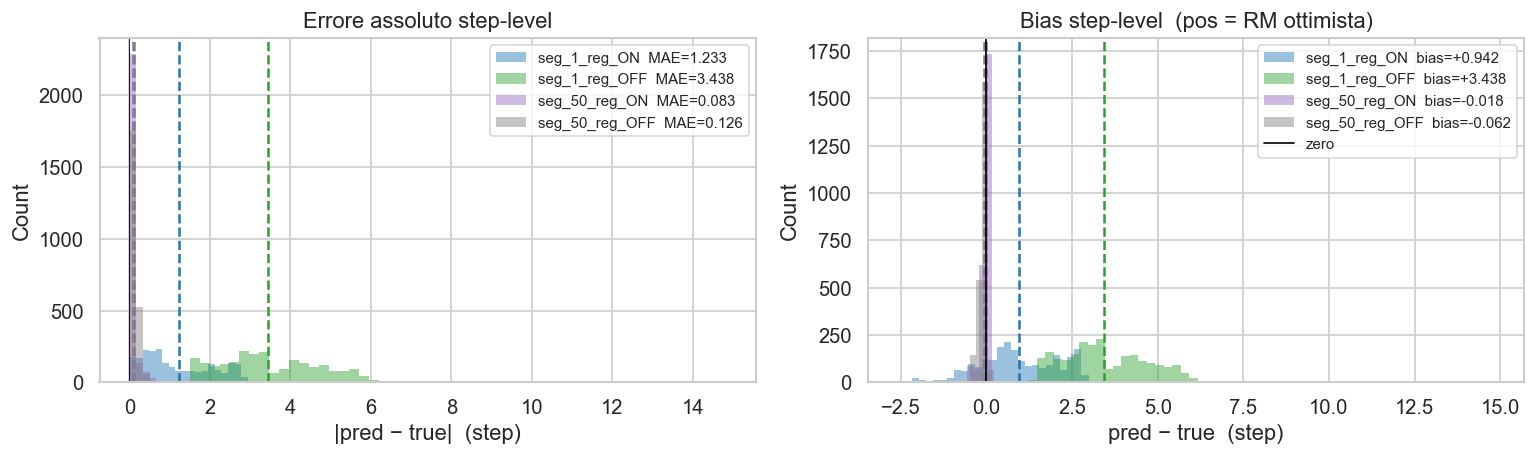

In [10]:
# ── 2. Distribuzione errore step-level ────────────────────────────────────
# Overlay degli istogrammi: semitrasparenti per leggere la sovrapposizione.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, r in runs.items():
    c = colors[label]
    abserr = np.abs(r["ae"])
    # Errore assoluto
    axes[0].hist(abserr, bins=60, color=c, alpha=0.45, edgecolor="none",
                 label=f"{label}  MAE={r['mae']:.3f}")
    axes[0].axvline(abserr.mean(), color=c, lw=1.5, ls="--")
    # Errore signed
    axes[1].hist(r["ae"], bins=60, color=c, alpha=0.45, edgecolor="none",
                 label=f"{label}  bias={r['bias']:+.3f}")
    axes[1].axvline(r["ae"].mean(), color=c, lw=1.5, ls="--")

axes[0].axvline(0, color="black", lw=0.5)
axes[1].axvline(0, color="black", lw=1.0, label="zero")

axes[0].set_xlabel("|pred − true|  (step)"); axes[0].set_ylabel("Count")
axes[0].set_title("Errore assoluto step-level"); axes[0].legend(fontsize=9)

axes[1].set_xlabel("pred − true  (step)"); axes[1].set_ylabel("Count")
axes[1].set_title("Bias step-level  (pos = RM ottimista)"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("crossrun_error_dist.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Istogrammi più stretti → RM più preciso
# Bias centrato su 0 → RM non sistematicamente ottimista/pessimista
# Coda destra pesante nell'errore assoluto → presenza di step OOD molto sbagliati

/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18323/3000115516.py:40: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18323/3000115516.py:41: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig("crossrun_calibration.png", dpi=150)


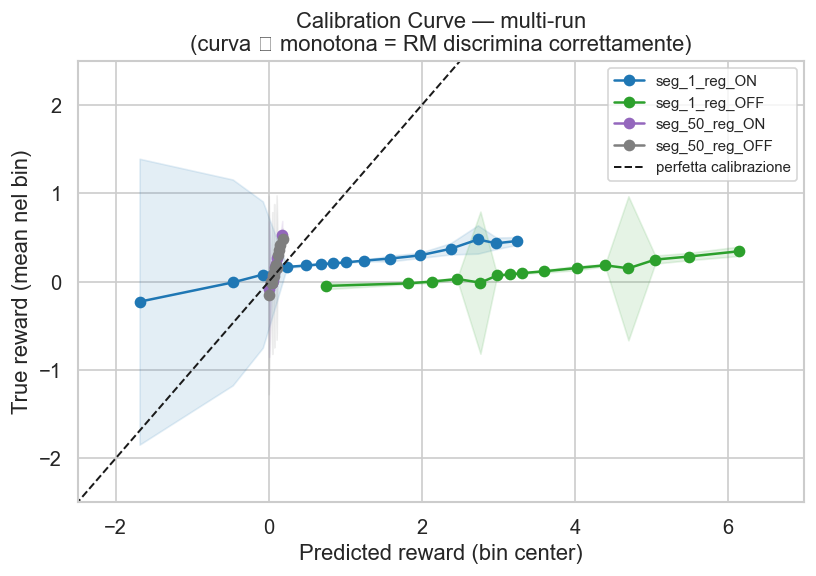

In [14]:
# ── 3. Calibration curve ──────────────────────────────────────────────────
# Una curva per run: bin del pred reward vs true reward medio nel bin.

N_BINS = 15

fig, ax = plt.subplots(figsize=(7, 5))

for label, r in runs.items():
    c  = colors[label]
    ap = r["ap"]
    at = r["at"]
    bins = np.percentile(ap, np.linspace(0, 100, N_BINS + 1))
    ctrs, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (ap >= lo) & (ap < hi)
        if mask.sum() < 5:
            continue
        ctrs.append((lo + hi) / 2)
        means.append(at[mask].mean())
        stds.append(at[mask].std())
    ctrs  = np.array(ctrs)
    means = np.array(means)
    stds  = np.array(stds)
    ax.plot(ctrs, means, "o-", color=c, lw=1.5, label=label)
    ax.fill_between(ctrs, means - stds, means + stds, color=c, alpha=0.12)

# Diagonale perfetta sul range comune
all_ap = np.concatenate([r["ap"] for r in runs.values()])
all_at = np.concatenate([r["at"] for r in runs.values()])
d_lo = min(all_ap.min(), all_at.min())
d_hi = max(all_ap.max(), all_at.max())
ax.plot([d_lo, d_hi], [d_lo, d_hi], "k--", lw=1.2, label="perfetta calibrazione")

ax.set_xlabel("Predicted reward (bin center)")
ax.set_xlim(-2.5,7)
ax.set_ylabel("True reward (mean nel bin)")
ax.set_ylim(-2.5,2.5)
ax.set_title("Calibration Curve — multi-run\n(curva ↗ monotona = RM discrimina correttamente)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("crossrun_calibration.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curva più vicina alla diagonale = migliore calibrazione assoluta
# Pendenza simile tra run ma traslazione verticale = bias costante diverso
# Curva piatta = il RM non discrimina indipendentemente dalla configurazione

/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18323/3029151091.py:62: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18323/3029151091.py:63: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.savefig("crossrun_logit_dist.png", dpi=150)


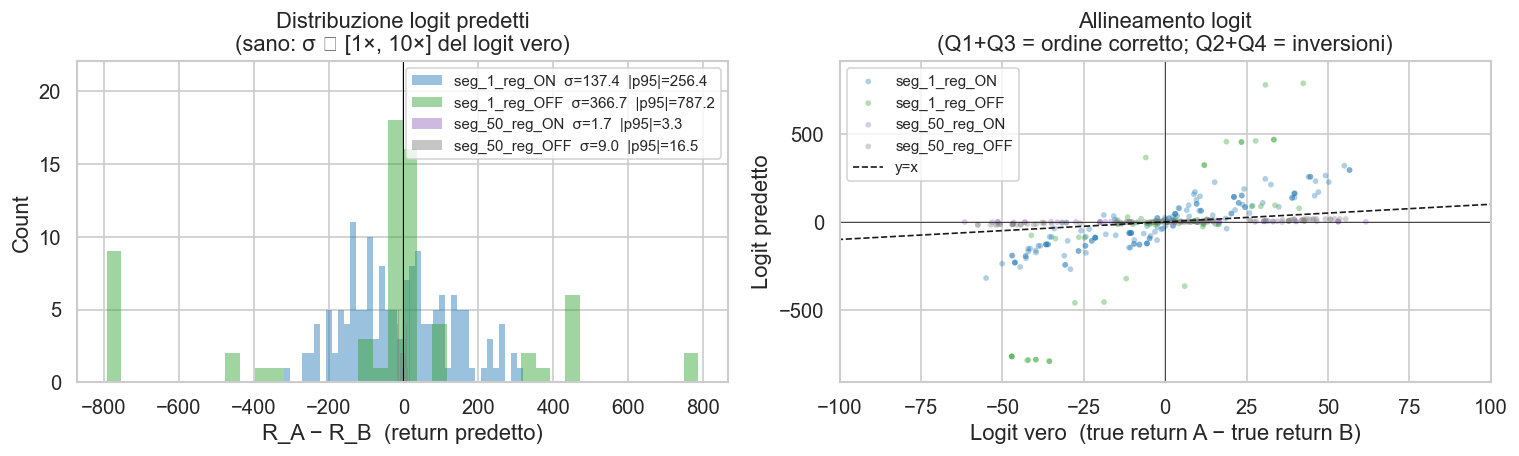

In [16]:
# ── 4. Logit distribution (da ritorni episodici) ──────────────────────────
# Logit = differenza di return predetto tra due episodi campionati a caso.
# Non richiede di ricaricare il reward model: usa ep_pr già in debug_data.
# Mostra se il RM è overconfident (|logit| molto grande) rispetto al logit
# vero (differenza di true return tra gli stessi episodi).

RNG = np.random.default_rng(42)
N_PAIRS = 500

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, r in runs.items():
    c    = colors[label]
    n_ep = r["n_ep"]
    ep_tr, ep_pr = r["ep_tr"], r["ep_pr"]

    n_pairs_eff = min(N_PAIRS, n_ep * (n_ep - 1) // 2)
    idx_pairs = [RNG.choice(n_ep, size=2, replace=False) for _ in range(n_pairs_eff)]

    lp = np.array([ep_pr[i] - ep_pr[j] for i, j in idx_pairs])
    lt = np.array([ep_tr[i] - ep_tr[j] for i, j in idx_pairs])

    sigma_p = lp.std()
    p95_p   = np.percentile(np.abs(lp), 95)

    axes[0].hist(lp, bins=40, color=c, alpha=0.45, edgecolor="none",
                 label=f"{label}  σ={sigma_p:.1f}  |p95|={p95_p:.1f}")
    axes[0].axvline(0, color="black", lw=0.6)

    # Scatter logit_vero vs logit_predetto
    idx_s = RNG.choice(len(lp), size=min(300, len(lp)), replace=False)
    axes[1].scatter(lt[idx_s], lp[idx_s], color=c, alpha=0.35, s=12,
                    edgecolors="none", label=label)

# Diagonale scatter
all_lt = np.concatenate([
    [r["ep_tr"][i] - r["ep_tr"][j]
     for i, j in [RNG.choice(r["n_ep"], 2, replace=False) for _ in range(200)]]
    for r in runs.values()
])
all_lp = np.concatenate([
    [r["ep_pr"][i] - r["ep_pr"][j]
     for i, j in [RNG.choice(r["n_ep"], 2, replace=False) for _ in range(200)]]
    for r in runs.values()
])
dl = (min(all_lt.min(), all_lp.min()) * 1.05,
      max(all_lt.max(), all_lp.max()) * 1.05)
axes[1].plot(dl, dl, "k--", lw=1.0, label="y=x")
axes[1].axhline(0, color="black", lw=0.4); axes[1].axvline(0, color="black", lw=0.4)

axes[0].set_xlabel("R_A − R_B  (return predetto)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribuzione logit predetti\n(sano: σ ∈ [1×, 10×] del logit vero)")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("Logit vero  (true return A − true return B)")
axes[1].set_xlim(-100, 100)
axes[1].set_ylabel("Logit predetto")
axes[1].set_title("Allineamento logit\n(Q1+Q3 = ordine corretto; Q2+Q4 = inversioni)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("crossrun_logit_dist.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# σ logit predetto simile tra run → la scala dei reward è comparabile
# σ logit predetto >> σ logit vero → il RM ha gonfiato la scala (overconfident)
# Punti in Q1+Q3 → preferenze coerenti; punti in Q2+Q4 → preferenze invertite

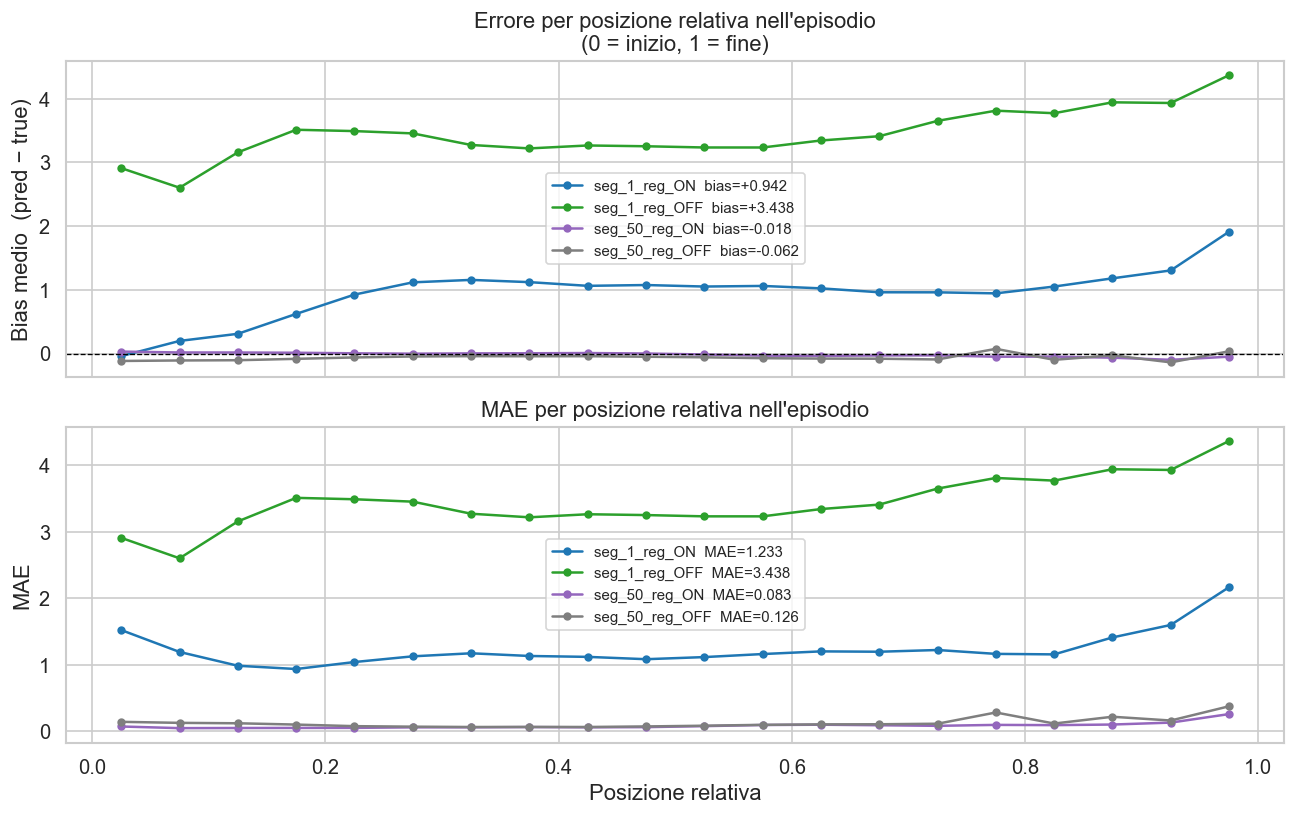

In [17]:
# ── 5. Errore per posizione nell'episodio ─────────────────────────────────
# Una linea per run: bias medio e MAE binned per posizione relativa [0,1].

N_BINS_POS = 20
bin_edges = np.linspace(0, 1, N_BINS_POS + 1)
bin_ctrs  = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for label, r in runs.items():
    c = colors[label]
    pos = np.concatenate([
        np.linspace(0, 1, len(t["true_rewards"]), endpoint=False)
        for t in r["trajs"]
    ])
    err = r["ae"]
    abserr = np.abs(err)

    bias_b, mae_b = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (pos >= lo) & (pos < hi)
        if mask.sum() < 3:
            bias_b.append(np.nan); mae_b.append(np.nan)
        else:
            bias_b.append(err[mask].mean())
            mae_b.append(abserr[mask].mean())

    bias_b = np.array(bias_b)
    mae_b  = np.array(mae_b)

    axes[0].plot(bin_ctrs, bias_b, "o-", color=c, lw=1.5, ms=4,
                 label=f"{label}  bias={r['bias']:+.3f}")
    axes[1].plot(bin_ctrs, mae_b, "o-", color=c, lw=1.5, ms=4,
                 label=f"{label}  MAE={r['mae']:.3f}")

axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_ylabel("Bias medio  (pred − true)")
axes[0].set_title("Errore per posizione relativa nell'episodio\n(0 = inizio, 1 = fine)")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("Posizione relativa")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE per posizione relativa nell'episodio")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("crossrun_error_by_position.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Linee piatte → errore casuale, non strutturato temporalmente
# Linea crescente verso fine ep → hacking temporalmente strutturato
# Run con linea più piatta = RM più stabile durante l'episodio

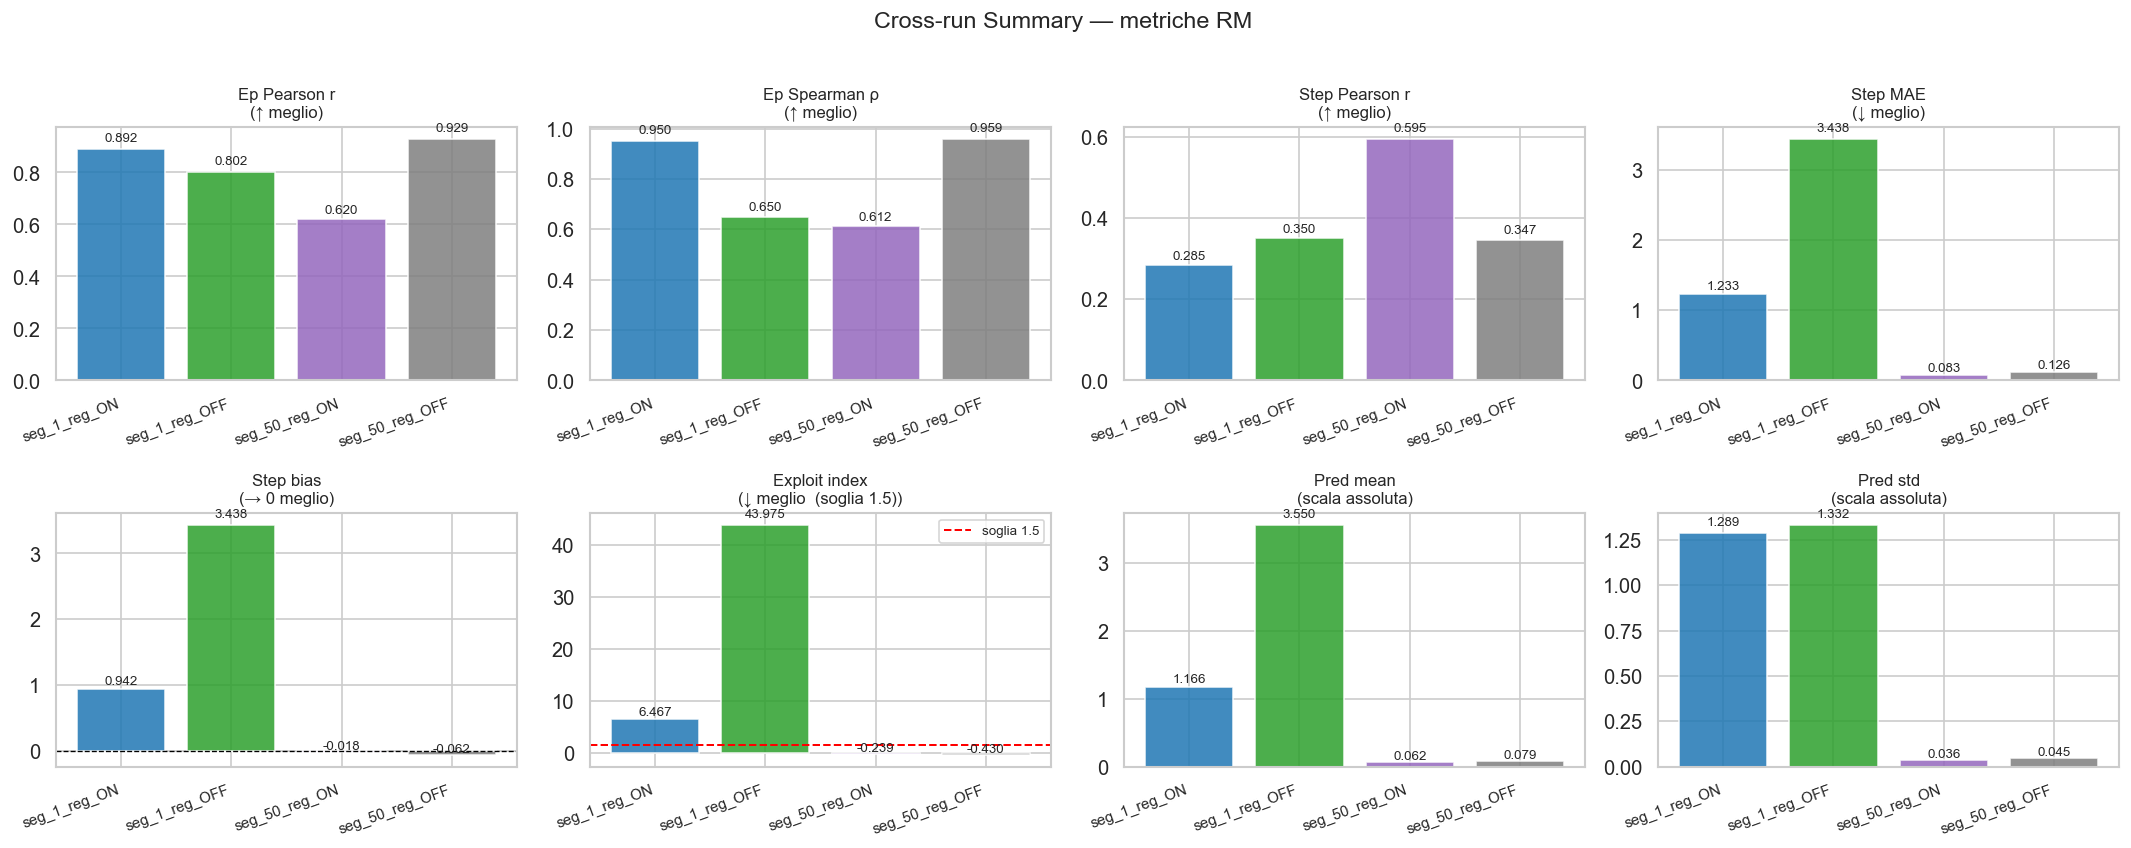


----------------------------------------------------------------------------------------------
Metrica                     seg_1_reg_ON     seg_1_reg_OFF     seg_50_reg_ON    seg_50_reg_OFF
----------------------------------------------------------------------------------------------
Ep Pearson r                      0.8919            0.8017            0.6200            0.9288
Ep Spearman ρ                     0.9505            0.6503            0.6121            0.9588
Step Pearson r                    0.2850            0.3501            0.5948            0.3466
Step MAE                          1.2333            3.4380            0.0830            0.1263
Step bias                         0.9420            3.4379           -0.0184           -0.0624
Exploit index                     6.4668           43.9752           -0.2386           -0.4299
Pred mean                         1.1656            3.5500            0.0621            0.0790
Pred std                          1.2895         

In [18]:
# ── 6. Summary: bar charts + tabella numerica ─────────────────────────────

METRICS = [
    ("p_ep",      "Ep Pearson r",    "↑ meglio"),
    ("s_ep",      "Ep Spearman ρ",   "↑ meglio"),
    ("p_st",      "Step Pearson r",  "↑ meglio"),
    ("mae",       "Step MAE",        "↓ meglio"),
    ("bias",      "Step bias",       "→ 0 meglio"),
    ("expl_idx",  "Exploit index",   "↓ meglio  (soglia 1.5)"),
    ("pred_mean", "Pred mean",       "scala assoluta"),
    ("pred_std",  "Pred std",        "scala assoluta"),
]

n_met = len(METRICS)
ncols = 4
nrows = (n_met + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
axes = axes.flatten()

x = np.arange(len(labels))
bar_colors = [colors[l] for l in labels]

for ai, (key, name, note) in enumerate(METRICS):
    vals = [runs[l][key] for l in labels]
    bars = axes[ai].bar(x, vals, color=bar_colors, alpha=0.85, edgecolor="white")
    axes[ai].set_xticks(x)
    axes[ai].set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    axes[ai].set_title(f"{name}\n({note})", fontsize=10)
    # Soglia exploit index
    if key == "expl_idx":
        axes[ai].axhline(1.5, color="red", lw=1.2, ls="--", label="soglia 1.5")
        axes[ai].legend(fontsize=8)
    # Soglia zero per bias
    if key == "bias":
        axes[ai].axhline(0, color="black", lw=0.8, ls="--")
    for bar, v in zip(bars, vals):
        ypos = bar.get_height() + abs(bar.get_height()) * 0.02
        axes[ai].text(bar.get_x() + bar.get_width() / 2, ypos,
                      f"{v:.3f}", ha="center", va="bottom", fontsize=8)

# Nasconde assi vuoti
for ai in range(n_met, len(axes)):
    axes[ai].set_visible(False)

plt.suptitle("Cross-run Summary — metriche RM", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("crossrun_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabella testuale ───────────────────────────────────────────────────────
col_w = 18
header = f"{'Metrica':<22}" + "".join(f"{l:>{col_w}}" for l in labels)
sep    = "-" * len(header)
print("\n" + sep)
print(header)
print(sep)
for key, name, note in METRICS:
    row = "".join(f"{runs[l][key]:>{col_w}.4f}" for l in labels)
    print(f"{name:<22}{row}")
print(sep)
print(f"{'N episodi':<22}" + "".join(f"{runs[l]['n_ep']:>{col_w}d}" for l in labels))
print(f"{'N step':<22}"    + "".join(f"{runs[l]['n_steps']:>{col_w}d}" for l in labels))
print(sep)

# ── Interpretazione ──────────────────────────────────────────────────────────
# Ep Pearson/Spearman: quanto il RM ordina correttamente gli episodi
# Step Pearson: quanto il RM è preciso step-by-step (atteso basso con seg=1)
# Exploit index > 1.5 → alert reward hacking
# Pred mean + std: confronta la scala assoluta tra configurazioni